# SDP per discriminazione di $n_x$ stati

Questo notebook riscrive il caso più semplice della pipeline:


$$\max W=\frac{1}{n_x}\sum_x \operatorname{Tr}(\rho_x M_x)$$

con vincoli fotonici, completezza POVM e localizing matrices, senza usare la classe  `TracialSDP`.

L'idea è costruire una singola variabile vettoriale

$$\alpha = (\alpha_0,\ldots,\alpha_{d-1})$$

dove ogni componente rappresenta un momento "tracciale" indipendente:

La matrice dei momenti non viene costruita creando una `cp.Variable` per ogni parola, ma come combinazione lineare:


$$\Gamma(\alpha)=F_0+\sum_i \alpha_i F_i \succeq 0$$

In pratica, ogni entry di $\Gamma$ è solo un riferimento a una componente di $\alpha$. $F$ è dunque una sorta di matrice di indici, che serve a tener conto della posizione di ogni traccia.

In [55]:
import math
from dataclasses import dataclass

import cvxpy as cp
import numpy as np
import matplotlib.pyplot as plt

## Algebra delle parole

Gli operatori sono rappresentati come stringhe:

- `r0`, `r1`, ... per gli stati $\rho_x$;
- `M0`, `M1`, ... per gli outcome POVM $M_b$;
- `s0`, `s1`, ... per i proiettori fotonici $\sigma_n$.

Usiamo le regole di ortogonalità ed idempotenza:

$$M_bM_{b'}=\delta_{bb'}M_b,
\qquad
\sigma_n\sigma_m=\delta_{nm}\sigma_n.$$

Inoltre, dentro la traccia usiamo ciclicità e inversione della parola, assumendo operatori hermitiani.

In [56]:
def reduce_word(w):
    """
    Riduce una parola usando idempotenza di POVM proiettive e sigma_n.
    Non mette a zero i prodotti ortogonali: quello lo fa is_zero_word.
    """
    w = list(w)
    changed = True

    while changed:
        changed = False
        out = []
        i = 0

        while i < len(w):
            if i + 1 < len(w):
                a, b = w[i], w[i + 1]

                if a == b and a.startswith("M"):
                    out.append(a)
                    i += 2
                    changed = True
                    continue

                if a == b and a.startswith("s"):
                    out.append(a)
                    i += 2
                    changed = True
                    continue

            out.append(w[i])
            i += 1

        w = out

    return tuple(w)


def is_zero_word(w):
    """
    Riconosce parole nulle per ortogonalità:
    M_b M_b' = 0 se b != b',
    sigma_n sigma_m = 0 se n != m.
    """
    w = tuple(w)

    for a, b in zip(w, w[1:]):
        if a.startswith("M") and b.startswith("M") and a != b:
            return True
        if a.startswith("s") and b.startswith("s") and a != b:
            return True

    return False


def rotations(w):
    w = tuple(w)
    if len(w) == 0:
        return [()]
    return [w[i:] + w[:i] for i in range(len(w))]


def canonical_word(w):
    """
    Forma canonica per Tr(w), usando:
    - riduzione algebrica;
    - ciclicità della traccia;
    - inversione della parola.
    """
    w = reduce_word(tuple(w))

    if is_zero_word(w):
        return None

    candidates = rotations(w) + rotations(tuple(reversed(w)))
    candidates = [reduce_word(c) for c in candidates]
    candidates = [c for c in candidates if not is_zero_word(c)]

    if not candidates:
        return None

    return min(candidates)


def dagger_word(w):
    """Gli operatori sono hermitiani, quindi u^dagger è la parola invertita."""
    return tuple(reversed(tuple(w)))


In [57]:
# Test rapidi
examples = [
    ("M0", "M0", "r0", "s0", "s0"),
    ("M0", "M1"),
    ("s0", "s1"),
    ("r0", "M1", "s0"),
    ("s0", "r0", "M1"),
    (),
]

for w in examples:
    print(w, "->", canonical_word(w))

('M0', 'M0', 'r0', 's0', 's0') -> ('M0', 'r0', 's0')
('M0', 'M1') -> None
('s0', 's1') -> None
('r0', 'M1', 's0') -> ('M1', 'r0', 's0')
('s0', 'r0', 'M1') -> ('M1', 'r0', 's0')
() -> ()


## Liste di operatori e parole della gerarchia

La gerarchia di parole è formulata nel modo seguente:
- identità;
- parole di livello 1;
- prodotti di livello 2;
- eventualmente alcune parole extra ($\rho M\sigma$, $M\rho\sigma$) gestite dalla booleana `include_extra`

Useremo `include_extra=False` per $n_x=2$ e `True` per $n_x=3,4$. Indipendentemente da $n_{\rm ntrunc}$. 

Per benchmark iniziale:
$$n_{\rm trunc}=0$$
Poi si passa allo studio di come l'aumentare di questa quantità benefici sulla randomness.

In [58]:
def build_operators(n_x, n_trunc):
    rhos = [f"r{x}" for x in range(n_x)]
    measurements = [f"M{b}" for b in range(n_x)]
    sigmas = [f"s{n}" for n in range(n_trunc + 1)]
    return rhos, measurements, sigmas


def unique_reduced_words(words):
    out = []
    seen = set()

    for w in words:
        w = reduce_word(tuple(w))
        if is_zero_word(w):
            continue
        if w not in seen:
            seen.add(w)
            out.append(w)

    return out


def build_words(n_x, n_trunc, include_extra=False):
    rhos, measurements, sigmas = build_operators(n_x, n_trunc)
    generators = rhos + measurements + sigmas

    words = [()]
    words += [(A,) for A in generators]
    words += [(A, B) for A in generators for B in generators]

    if include_extra:
        words += [(r, M, s) for r in rhos for M in measurements for s in sigmas]
        words += [(M, r, s) for M in measurements for r in rhos for s in sigmas]

    return unique_reduced_words(words)


def build_localizing_words(n_x, n_trunc):
    rhos, measurements, sigmas = build_operators(n_x, n_trunc)

    words = [()]
    words += [(r,) for r in rhos]
    words += [(M,) for M in measurements]
    words += [(s,) for s in sigmas]

    return unique_reduced_words(words)


def build_completeness_words(n_x, n_trunc, mode="loc"):
    """
    mode='loc': usa le stesse parole della localizing matrix.
    mode='extended': aggiunge parole più forti.
    """
    rhos, measurements, sigmas = build_operators(n_x, n_trunc)

    if mode == "loc":
        return build_localizing_words(n_x, n_trunc)

    if mode == "extended":
        words = build_localizing_words(n_x, n_trunc)
        words += [(r, M) for r in rhos for M in measurements]
        words += [(r, s) for r in rhos for s in sigmas]
        words += [(s, M) for s in sigmas for M in measurements]
        return unique_reduced_words(words)

    raise ValueError("mode deve essere 'loc' oppure 'extended'.")

## Base dei momenti $\alpha$

Voglio qualcosa tipo:

```python
word_to_idx[word] = i
alpha[i] = Tr(word)
```

Quindi ogni momento è una coordinata di un unico vettore. In questo modo, lavoro solo sul vettore $\vec{\alpha}$.

In [59]:
class MomentBasis:
    """
    Dizionario parola canonica -> indice alpha.
    """
    def __init__(self):
        self.word_to_idx = {}
        self.idx_to_word = []

    def add(self, w):
        key = canonical_word(w)
        if key is None:
            return None

        if key not in self.word_to_idx:
            self.word_to_idx[key] = len(self.idx_to_word)
            self.idx_to_word.append(key)

        return self.word_to_idx[key]

    def __len__(self):
        return len(self.idx_to_word)


def add_entry_to_row(row, basis, w, coeff):
    """
    Funzione che crea l'algebra per lavorare sui coefficienti del vettore di base dei momenti.
    'Row' è un dizionario che associa indici di parola canonica a coefficienti:
    se l'indice non è presente, il coefficiente è 0, se l'indice è presente, i coefficienti si sommano.
    """
    idx = basis.add(w)
    if idx is None:
        return row

    row[idx] = row.get(idx, 0.0) + float(coeff)
    return row


def dense_row_from_dict(row_dict, d):
    """
    Questa funzione serve perché bisogna passare a CVXPY un array. Dunque dal dizionario row_dict, che rappresenta una riga sparsa,
    (indice parola canonica -> coefficiente), si costruisce un array denso di dimensione d.
    """
    row = np.zeros(d)
    for k, v in row_dict.items():
        row[k] += v
    return row

## Pre-costruzione del modello simbolico

Costruzione del modello: dovrà contenere tutte le parole che potranno apparire in:

- matrice dei momenti $\Gamma$;
- localizing matrices $\gamma_x$;
- normalizzazioni;
- vincoli fotonici;
- completezza POVMs;
- obiettivo (in questo caso, discrimination witness).


In [60]:
@dataclass #Per non scrivere il costruttore
class SymbolicDiscriminationModel:
    n_x: int
    n_trunc: int
    words: list
    loc_words: list
    completeness_words: list
    rhos: list
    measurements: list
    sigmas: list
    basis: MomentBasis
    Gamma_idx: np.ndarray
    Lplus_idx: dict
    Lminus_idx: dict
    Aeq: np.ndarray
    beq: np.ndarray
    photon_rows: list
    objective_row: np.ndarray


def matrix_indices_from_words(basis, words, middle=()):
    """
    Restituisce una matrice di indici K tale che:
    K[i,j] = indice di alpha associato a Tr(u_i^dagger 'middle' v_j),
    oppure -1 se la parola è nulla. (-1 serve solo come flag poi per non salvare in alpha la traccia nulla)
    """
    n = len(words)
    K = -np.ones((n, n), dtype=int)

    for i, u in enumerate(words):
        for j, v in enumerate(words):
            w = dagger_word(u) + tuple(middle) + tuple(v)
            idx = basis.add(w)
            if idx is not None:
                K[i, j] = idx

    return K


def collect_symbolic_model(n_x, n_trunc, include_extra=False, completeness_mode="loc"):
    rhos, measurements, sigmas = build_operators(n_x, n_trunc)
    words = build_words(n_x, n_trunc, include_extra=include_extra)
    loc_words = build_localizing_words(n_x, n_trunc)
    completeness_words = build_completeness_words(n_x, n_trunc, mode=completeness_mode)

    basis = MomentBasis()

    # 1) Gamma
    Gamma_idx = matrix_indices_from_words(basis, words)

    # 2) Localizing matrices:
    # L_x[u,v] = Tr(u^dagger rho_x v) - Tr(u^dagger rho_x rho_x v)
    # Conviene trattare separatamente i due termini, in due dizionari che associano a ciascun rho_x la matrice di indici corrispondente.
    Lplus_idx = {}
    Lminus_idx = {}

    for r in rhos:
        Lplus_idx[r] = matrix_indices_from_words(basis, loc_words, middle=(r,))
        Lminus_idx[r] = matrix_indices_from_words(basis, loc_words, middle=(r, r))

    # 3) Normalizzazioni e completezza: prima come righe sparse
    eq_rows = []
    eq_vals = []

    # Tr(rho_x)=1
    for r in rhos:
        row = {}
        add_entry_to_row(row, basis, (r,), +1.0)
        eq_rows.append(row)
        eq_vals.append(1.0)

    # Tr(sigma_n)=1
    for s in sigmas:
        row = {}
        add_entry_to_row(row, basis, (s,), +1.0)
        eq_rows.append(row)
        eq_vals.append(1.0)

    # Completezza: sum_b Tr(u^dagger M_b v) = Tr(u^dagger v)
    for u in completeness_words:
        for v in completeness_words:
            row = {}

            for M in measurements:
                add_entry_to_row(row, basis, dagger_word(u) + (M,) + tuple(v), +1.0)

            add_entry_to_row(row, basis, dagger_word(u) + tuple(v), -1.0)

            # Scarta righe identicamente nulle
            row = {k: val for k, val in row.items() if abs(val) > 1e-12}
            if row:
                eq_rows.append(row)
                eq_vals.append(0.0)

    # 4) Photon rows: Tr(rho_x sigma_n) >= 1 - omega[x,n]
    photon_rows_sparse = []
    for x, r in enumerate(rhos):
        for n, s in enumerate(sigmas):
            row = {}
            add_entry_to_row(row, basis, (r, s), +1.0)
            photon_rows_sparse.append((x, n, row))

    # 5) Objective W = 1/n_x sum_x Tr(rho_x M_x)
    obj_sparse = {}
    for x, r in enumerate(rhos):
        M = measurements[x]
        add_entry_to_row(obj_sparse, basis, (r, M), 1.0 / n_x)

    # Ora conosciamo d = numero totale di momenti e creiamo le matrici / vettori densi per CVXPY
    d = len(basis)

    Aeq = np.vstack([dense_row_from_dict(row, d) for row in eq_rows]) if eq_rows else np.zeros((0, d))
    beq = np.asarray(eq_vals, dtype=float)

    photon_rows = []
    for x, n, row in photon_rows_sparse:
        photon_rows.append((x, n, dense_row_from_dict(row, d)))

    objective_row = dense_row_from_dict(obj_sparse, d)

    return SymbolicDiscriminationModel(
        n_x=n_x,
        n_trunc=n_trunc,
        words=words,
        loc_words=loc_words,
        completeness_words=completeness_words,
        rhos=rhos,
        measurements=measurements,
        sigmas=sigmas,
        basis=basis,
        Gamma_idx=Gamma_idx,
        Lplus_idx=Lplus_idx,
        Lminus_idx=Lminus_idx,
        Aeq=Aeq,
        beq=beq,
        photon_rows=photon_rows,
        objective_row=objective_row,
    )

## Da matrici di indici a espressioni CVXPY

Se una entry della matrice ha indice $k$, allora quella entry è $\alpha_k$.

La funzione seguente trasforma una matrice di indici in una matrice CVXPY ().

In [61]:
def expr_from_index_matrix(K, alpha_expr):
    """
    Converte una matrice K di indici in una matrice CVXPY.
    Usato per costruire la matrice dei momenti Gamma e i due termini per la localizing a partire dagli indici associati alle parole canoniche.
    K[i,j] = k  -> alpha_expr[k]
    K[i,j] = -1 -> 0
    """
    rows = []

    for i in range(K.shape[0]):
        row = []
        for j in range(K.shape[1]):
            k = int(K[i, j])
            if k < 0:
                row.append(0.0)
            else:
                row.append(alpha_expr[k])
        rows.append(row)

    return cp.bmat(rows)


def localizing_expr(model, r, alpha_expr):
    Lplus = expr_from_index_matrix(model.Lplus_idx[r], alpha_expr)
    Lminus = expr_from_index_matrix(model.Lminus_idx[r], alpha_expr)
    return Lplus - Lminus

## Eliminazione opzionale dei vincoli lineari

I vincoli lineari sono:

$$A\alpha=b.$$

Possiamo lasciarli al solver, oppure risolverli eliminandoli prima.

Se troviamo:

$$\alpha=\alpha_0+N\beta$$

con

$$A\alpha_0=b,\qquad AN=0$$

allora il solver lavora solo sulle variabili libere $\beta$.

## Solver SDP per discriminazione
Scegliere:

- `eliminate_equalities=False`: tiene $A\alpha=b$ come vincolo CVXPY;
- `eliminate_equalities=True`: sostituisce $\alpha=\alpha_0+N\beta$, risolvendo il vincolo e allegerendo il job del solver.

In [62]:
def poisson_photon_weights(N, n_trunc):
    return np.array([np.exp(-N) * N**n / math.factorial(n) for n in range(n_trunc + 1)])


def poisson_omega(N, n_x, n_trunc):
    probn = poisson_photon_weights(N, n_trunc)
    omega_row = 1 - probn
    return np.tile(omega_row, (n_x, 1))


def solve_discrimination_witness(
    n_x,
    n_trunc,
    omega,
    include_extra=False,
    completeness_mode="loc",
    eliminate_equalities=False,
    solver="MOSEK",
    verbose=False,
    psd_tol=0.0,
):
    """
    SDP per n-state discrimination con formulazione:
    max c^T alpha
    s.t. Gamma(alpha) >= 0
         L_x(alpha) >= 0
         A alpha = b (normalizzazioni e completezza POVMs)
         photon constraints
    """
    omega = np.asarray(omega, dtype=float)
    assert omega.shape == (n_x, n_trunc + 1)

    #print(f"Preparo il modello simbolico...")
    model = collect_symbolic_model(n_x=n_x, n_trunc=n_trunc, include_extra=include_extra, completeness_mode=completeness_mode,)
    #print(f"FATTO")

    d = len(model.basis)
    constraints = []

    alpha = cp.Variable(d, name="alpha")
    alpha_expr = alpha

    #print(f"Aggiungendo i constraint 'model.Aeq @ alpha == model.beq'...")
    if model.Aeq.shape[0] > 0:
        constraints.append(model.Aeq @ alpha == model.beq)
    #print(f"FATTO")

    # da modificare quando si entra in eliminate_equalities=True
    info = {
        "eliminated": False,
        "d_alpha_original": d,
        "d_beta": d,
        "num_equalities": model.Aeq.shape[0]
    }

    # PSD Gamma
    #print(f"Aggiungendo i constraint 'Gamma >> 0'...")
    Gamma = expr_from_index_matrix(model.Gamma_idx, alpha_expr)
    nG = len(model.words)
    constraints.append(Gamma >> psd_tol * np.eye(nG))
    #print(f"FATTO")

    #print(f"Aggiungendo i constraint 'localizing >> 0'...")
    # PSD localizing matrices
    for r in model.rhos:
        Lr = localizing_expr(model, r, alpha_expr)
        nL = len(model.loc_words)
        constraints.append(Lr >> psd_tol * np.eye(nL))
    #print(f"FATTO")

    #print(f"Aggiungendo i photon constraint...")
    # Photon constraints
    for x, n, row in model.photon_rows:
        constraints.append(row @ alpha_expr >= 1.0 - omega[x, n])
        constraints.append(row @ alpha_expr <= 1.0)
    #print(f"FATTO")

    #print(f"Preparando l'obiettivo...")
    objective = model.objective_row @ alpha_expr
    #print(f"FATTO")
    
    #print(f"Risolvendo l' SDP...")
    problem = cp.Problem(cp.Maximize(objective), constraints)
    problem.solve(solver=solver, verbose=verbose)
    #print(f"FATTO")

    alpha_value = None
    if problem.status in ("optimal", "optimal_inaccurate"):
        try:
            alpha_value = np.asarray(alpha_expr.value, dtype=float).reshape(-1)
        except Exception:
            alpha_value = None

    return {
        "problem": problem,
        "model": model,
        "status": problem.status,
        "sdp_upper_bound": problem.value,
        "alpha_value": alpha_value,
        "solver": solver,
        **info,
        "num_words": len(model.words),
        "num_loc_words": len(model.loc_words),
        "num_moment_variables": d,
        "num_constraints_cvxpy": len(constraints),
    }

## Ispezione del modello

Prima di risolvere, conviene sempre guardare:

- quante parole ci sono;
- quanti momenti indipendenti $\alpha_i$;
- quante uguaglianze lineari;
- quanti gradi di libertà restano dopo eliminazione.

Questa parte è fondamentale per capire il guadagno della nuova formulazione.

In [63]:
def summarize_model(n_x=2, n_trunc=0, include_extra=False, completeness_mode="loc"):
    model = collect_symbolic_model(n_x=n_x, n_trunc=n_trunc, include_extra=include_extra, completeness_mode=completeness_mode)

    print(f"n_x = {n_x}, n_trunc = {n_trunc}")
    print(f"num words Gamma          = {len(model.words)}")
    print(f"num loc words            = {len(model.loc_words)}")
    print(f"num alpha moments        = {len(model.basis)}")
    print(f"num equalities Aalpha=b  = {model.Aeq.shape[0]}")

    print("\nPrime componenti alpha:")
    for i, w in enumerate(model.basis.idx_to_word[:30]):
        print(f"{i:4d}: {w}")

    return model


model_test = summarize_model(n_x=2, n_trunc=0, include_extra=False, completeness_mode="loc")

n_x = 2, n_trunc = 0
num words Gamma          = 26
num loc words            = 6
num alpha moments        = 108
num equalities Aalpha=b  = 19

Prime componenti alpha:
   0: ()
   1: ('r0',)
   2: ('r1',)
   3: ('M0',)
   4: ('M1',)
   5: ('s0',)
   6: ('r0', 'r0')
   7: ('r0', 'r1')
   8: ('M0', 'r0')
   9: ('M1', 'r0')
  10: ('r0', 's0')
  11: ('r1', 'r1')
  12: ('M0', 'r1')
  13: ('M1', 'r1')
  14: ('r1', 's0')
  15: ('M0', 's0')
  16: ('M1', 's0')
  17: ('r0', 'r0', 'r0')
  18: ('r0', 'r0', 'r1')
  19: ('M0', 'r0', 'r0')
  20: ('M1', 'r0', 'r0')
  21: ('r0', 'r0', 's0')
  22: ('r0', 'r1', 'r1')
  23: ('M0', 'r0', 'r1')
  24: ('M1', 'r0', 'r1')
  25: ('r0', 'r1', 's0')
  26: ('M0', 'r0', 's0')
  27: ('M1', 'r0', 's0')
  28: ('r1', 'r1', 'r1')
  29: ('M0', 'r1', 'r1')


## Primo test (singolo punto) su solver
Consideriamo un valore per N da cui ricaviamo $\omega$ da passare alla funzione SDP. Confronteremo poi i vari risultati per ```eliminate_equalities=False/True```.

In [64]:
N_value = 0.1
n_x = 2
n_trunc = 0

omega = poisson_omega(N_value, n_x=n_x, n_trunc=n_trunc)

res = solve_discrimination_witness(
    n_x=n_x,
    n_trunc=n_trunc,
    omega=omega,
    include_extra=False,
    completeness_mode="loc",
    eliminate_equalities=False,
    verbose=False,
)

print("status:", res["status"])
print("solver:", res["solver"])
print("W upper bound:", res["sdp_upper_bound"])
print("original alpha dimension:", res["d_alpha_original"])
print("free beta dimension:", res["d_beta"])
print("num equalities:", res["num_equalities"])

status: optimal
solver: MOSEK
W upper bound: 0.7934393677069609
original alpha dimension: 108
free beta dimension: 108
num equalities: 19


## 10. Confronto: con e senza eliminazione

Idealmente i valori del witness devono coincidere entro tolleranza numerica.

La versione con eliminazione dovrebbe avere meno variabili libere.

In [65]:
res_noelim = solve_discrimination_witness(
    n_x=2,
    n_trunc=0,
    omega=omega,
    include_extra=False,
    completeness_mode="loc",
    eliminate_equalities=False,
    verbose=False,
)

res_elim = solve_discrimination_witness(
    n_x=2,
    n_trunc=0,
    omega=omega,
    include_extra=False,
    completeness_mode="loc",
    eliminate_equalities=False,
    verbose=False,
)

print("\nWithout elimination:")
print("  status:", res_noelim["status"])
print("  W:", res_noelim["sdp_upper_bound"])
print("  alpha dim:", res_noelim["d_alpha_original"])

print("With elimination:")
print("  status:", res_elim["status"])
print("  W:", res_elim["sdp_upper_bound"])
print("  beta dim:", res_elim["d_beta"])

print("\nDifference:", abs(res_noelim["sdp_upper_bound"] - res_elim["sdp_upper_bound"]))


Without elimination:
  status: optimal
  W: 0.7934393677069609
  alpha dim: 108
With elimination:
  status: optimal
  W: 0.7934393677069609
  beta dim: 108

Difference: 0.0


## Check: $n_x=2$, $n_{\rm trunc}=0$

Per $n_x=2$, $n_{\mathrm{trunc}}=0$, il risultato analitico atteso è

$$
W_{2\mathrm{disc}} = \frac12 + \sqrt{\omega(1-\omega)}.
$$

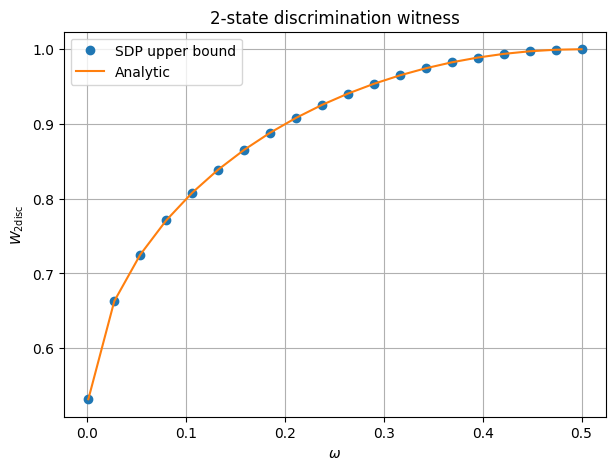

In [66]:
omegas = np.linspace(0.001, 0.5, 20)
results_2 = []
analytics2 = []
for omega in omegas:
    res = solve_discrimination_witness(
        n_x=2,
        n_trunc=0,
        omega=np.tile(omega, (n_x, 1)),
        include_extra=False,
        completeness_mode="loc",
        eliminate_equalities=False,
        verbose=False
    )
    analytic = 0.5 + np.sqrt(omega * (1 - omega))
    res["analytic"] = analytic
    res["absolute_error"] = None if res["sdp_upper_bound"] is None else abs(res["sdp_upper_bound"] - analytic)
    results_2.append(res["sdp_upper_bound"])
    analytics2.append(res["analytic"])

plt.figure(figsize=(7, 5))
plt.plot(omegas, results_2, "o", label="SDP upper bound")
plt.plot(omegas, analytics2, "-", label="Analytic")
plt.xlabel(r"$\omega$")
plt.ylabel(r"$W_{2\mathrm{disc}}$")
plt.title("2-state discrimination witness")
plt.legend()
plt.grid(True)
plt.show()

## $n_x=3$, solo vincolo sul vuoto

Nel caso con tre stati e solo vincolo sul vuoto, un riferimento utile è

$$
W_{3\mathrm{disc}} = \frac{1+\omega}{3} + \frac{2\sqrt{2}}{3}\sqrt{\omega(1-\omega)}.
$$

A seconda del livello del rilassamento, il bound SDP può essere più o meno stretto.

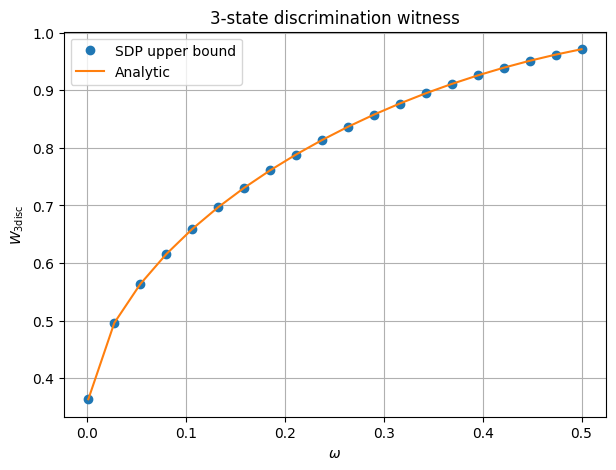

In [67]:
def analytic_three_state_vacuum(omega):
    return (1 + omega) / 3 + (2 * np.sqrt(2) / 3) * np.sqrt(omega * (1 - omega))

omegas = np.linspace(0.001, 0.5, 20)
n_x=3
n_trunc=0
results_3 = []
analytics3 = []
for omega in omegas:
    res = solve_discrimination_witness(
        n_x=n_x,
        n_trunc=n_trunc,
        omega=np.tile(omega, (n_x, 1)),
        solver="MOSEK",
        include_extra=True,
        completeness_mode="loc",
        eliminate_equalities=False,
        verbose=False
    )
    analytic = analytic_three_state_vacuum(omega)
    res["analytic"] = analytic
    res["absolute_error"] = None if res["sdp_upper_bound"] is None else abs(res["sdp_upper_bound"] - analytic)
    results_3.append(res["sdp_upper_bound"])
    analytics3.append(res["analytic"])

plt.figure(figsize=(7, 5))
plt.plot(omegas, results_3, "o", label="SDP upper bound")
plt.plot(omegas, analytics3, "-", label="Analytic")
plt.xlabel(r"$\omega$")
plt.ylabel(r"$W_{3\mathrm{disc}}$")
plt.title("3-state discrimination witness")
plt.legend()
plt.grid(True)
plt.show()

## $n_x=4$, solo vincolo sul vuoto

Nel caso con quattro stati e solo vincolo sul vuoto, un riferimento utile è

$$
W_{3\mathrm{disc}} = \frac{1+2\omega}{4} + \frac{\sqrt{3}}{2}\sqrt{\omega(1-\omega)}.
$$

A seconda del livello del rilassamento, il bound SDP può essere più o meno stretto.

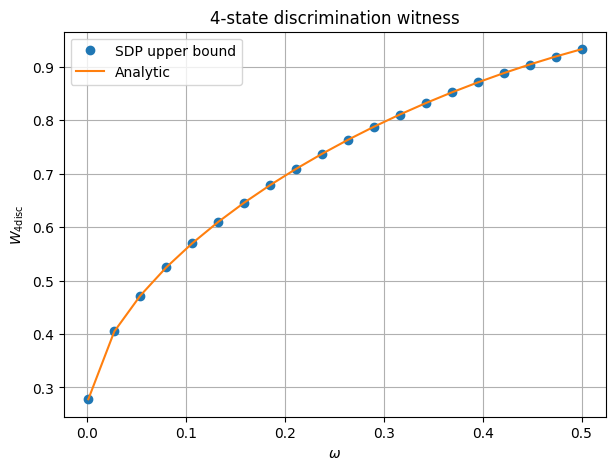

In [68]:
def analytic_four_state_vacuum(omega):
    return (1 + 2* omega) / 4 + (np.sqrt(3) / 2) * np.sqrt(omega * (1 - omega))

omegas = np.linspace(0.001, 0.5, 20)
n_x=4
n_trunc=0
results_4 = []
analytics4 = []
for omega in omegas:
    res = solve_discrimination_witness(
        n_x=n_x,
        n_trunc=n_trunc,
        omega=np.tile(omega, (n_x, 1)),
        solver="MOSEK",
        include_extra=True,
        completeness_mode="loc",
        eliminate_equalities=False,
        verbose=False
    )
    analytic = analytic_four_state_vacuum(omega)
    res["analytic"] = analytic
    res["absolute_error"] = None if res["sdp_upper_bound"] is None else abs(res["sdp_upper_bound"] - analytic)
    results_4.append(res["sdp_upper_bound"])
    analytics4.append(res["analytic"])

plt.figure(figsize=(7, 5))
plt.plot(omegas, results_4, "o", label="SDP upper bound")
plt.plot(omegas, analytics4, "-", label="Analytic")
plt.xlabel(r"$\omega$")
plt.ylabel(r"$W_{4\mathrm{disc}}$")
plt.title("4-state discrimination witness")
plt.legend()
plt.grid(True)
plt.show()